In [1]:
!pip uninstall -y vllm torch torchvision torchaudio torchcodec
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install vllm
!pip uninstall -y torchcodec


Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Found existing installation: torchcodec 0.10.0+cu128
Uninstalling torchcodec-0.10.0+cu128:
  Successfully uninstalled torchcodec-0.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 112.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 39.1 

# Analisi e Simulazione: La co-evoluzione di un sistema agentico in una rete sociale
## Pipeline Completa: Fase 0 → Fase 1 → Fase 2 → Fase 3

Questo notebook esegue la pipeline completa del framework in sequenza.

| Fase | Titolo | Moduli chiave |
|------|--------|---------------|
| **0** | Setup & Baseline | `data_loader`, `extractor` (Forest Fire sampling), `community`, `metrics` |
| **1** | Logica Agente | `agent`, `llm_client`, `state_machine`, `seeder` |
| **2** | Co-evoluzione | `orchestrator`, `gnn`, `rewirer`, `checkpoint` |
| **3** | CELF Fact-Checking | `celf`, `injector`, `influence/metrics` |

> ⚙️ **Configurazione**: modifica `config.yaml` o i parametri nella cella di setup per personalizzare la simulazione.
>
> 🌲 **Sampling**: il sottografo viene estratto con l'algoritmo **Forest Fire** (Leskovec & Faloutsos, KDD 2006) che preserva meglio le proprietà strutturali (distribuzione gradi, clustering, comunità) rispetto a BFS/Random Walk.

## 0. Setup Ambiente

In [2]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_1 = user_secrets.get_secret("HF_TOKEN")


os.environ["HF_TOKEN"] = secret_value_1

print("✅ Variabili d'ambiente impostate:")
print(f"   HF_TOKEN       = {'*' * 8}{secret_value_1[-4:]}")

import site
os.environ["LD_LIBRARY_PATH"] = f"{site.getsitepackages()[0]}/nvidia/cuda_nvrtc/lib:" + os.environ.get("LD_LIBRARY_PATH", "")


✅ Variabili d'ambiente impostate:
   HF_TOKEN       = ********CzyV


In [3]:
import sys
import os
from pathlib import Path

# --- Path setup (compatibile locale + Kaggle) ---
if Path('/kaggle/working').exists():
    # Kaggle: clona il repo nella working dir
    PROJECT_ROOT = Path('/kaggle/working/progetto')
    if not PROJECT_ROOT.exists():
        os.system('git clone https://github.com/stefaano19/progettoASM /kaggle/working/progetto')
        os.system('NUMPY_VER=$(python -c "import numpy; print(numpy.__version__)") && pip install -r /kaggle/working/progetto/requirements.txt && pip install --force-reinstall --no-deps numpy==$NUMPY_VER')
else:
    # Locale: la project root è due livelli sopra il notebook
    PROJECT_ROOT = Path('..').resolve()

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version}')

Cloning into '/kaggle/working/progetto'...


INFO: pip is looking at multiple versions of notebook to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.8/529.8 kB 34.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.35.1
    Uninstalling protobuf-7.35.1:
      Successfully uninstalled protobuf-7.35.1
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipyker

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.25.1 requires torchcodec>=0.14, which is not installed.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.9.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.43.0 which is incompatible.
google-adk 1.29.0 requires ope

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 84.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
Project root: /kaggle/working/progetto
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [4]:
# 4. Installa i requirement del progetto
!pip install -r requirements.txt


## 0.1 Setup vLLM (LLM Locale ad altissime prestazioni)
Sostituiamo Ollama con vLLM per sfruttare il **Continuous Batching**. Questo abbatterà i tempi da 12 ore a pochi minuti.

In [5]:
# --- Download preventivo per evitare instabilità di rete (403 Forbidden) ---
!pip install -U huggingface_hub
!hf download casperhansen/llama-3-8b-instruct-awq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.1 MB/s eta 0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.4.3
    Uninstalling hf-xet-1.4.3:
      Successfully uninstalled hf-xet-1.4.3
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-

In [6]:
# --- Avvio server vLLM (OpenAI Compatible) ---
import subprocess, os, time

# Usiamo il modello AWQ quantizzato per farlo stare comodo nei 15GB della singola T4 di Kaggle,
# oppure usiamo tensor parallel su 2 GPU.
MODEL_NAME = "casperhansen/llama-3-8b-instruct-awq" # 4-bit quantizzato, veloce e leggero

env = os.environ.copy()
env['VLLM_ATTENTION_BACKEND'] = 'xformers'
env['VLLM_DISABLE_MARLIN'] = '1'
env['VLLM_USE_MARLIN'] = '0'
subprocess.Popen(
    ['python', '-m', 'vllm.entrypoints.openai.api_server',
     '--model', MODEL_NAME,
     '--quantization', 'awq',
     '--dtype', 'half',
     '--max-model-len', '4096',
     '--port', '8000',
     '--gpu-memory-utilization', '0.90'],
    stdout=open('vllm.log', 'w'),
    stderr=subprocess.STDOUT,
    env=env,
)
print("⏳ Avvio vLLM in background (potrebbe richiedere 1-3 minuti)...\n")
time.sleep(10) # Pausa iniziale


⏳ Avvio vLLM in background (potrebbe richiedere 1-3 minuti)...



In [7]:
import requests, time

# Healthcheck vLLM
ok = False
for i in range(40):
    try:
        response = requests.get('http://localhost:8000/v1/models', timeout=2)
        if response.status_code == 200:
            ok = True
            break
    except Exception:
        pass
    time.sleep(5)

if ok:
    models = [m['id'] for m in response.json().get('data', [])]
    print(f'✅ vLLM è online! Modelli: {models}')
else:
    print('❌ Errore: vLLM non sta rispondendo')
    !tail -n 30 vllm.log


✅ vLLM è online! Modelli: ['casperhansen/llama-3-8b-instruct-awq']


In [8]:
# Parametri globali della pipeline
# Modifica qui invece di editare config.yaml

CONFIG_PATH       = 'config.yaml'
USE_MOCK_LLM      = False       # False = usa il vero LLM
PHASE2_STEPS      = 0          # N. step da eseguire IN QUESTA SESSIONE (non totali!)
PHASE3_STEPS      = 5           # Step post-intervento
CELF_BUDGET_K     = 10          # Fact-checker da iniettare
SKIP_DOWNLOAD     = True        # True se ogbl-collab e' gia' in cache
RESUME_FROM_CKPT  = True       # True per riprendere da checkpoint Fase 2

# --- Sampling (Forest Fire) ---
SAMPLING_STRATEGY = 'forest_fire'  # bfs_seed | random_walk | random_nodes | forest_fire
FOREST_FIRE_PROB  = 0.5            # Forward probability (0.4-0.7); piu' alto = piu' denso
TARGET_NODES      = 5000         # Nodi target nel sottografo

# --- Checkpoint cross-versione Kaggle ---
# Se stai riprendendo da una versione precedente:
#   1. Aggiungi l'output della versione precedente come dataset input
#   2. Imposta PREV_VERSION_CKPT_INPUT al path del file .pkl
#   3. Imposta RESUME_FROM_CKPT = True
PREV_VERSION_CKPT_INPUT = "/kaggle/input/notebooks/developerstefa/notebookdefsnm/ckpt_step_0093.pkl"  # Path del .pkl dalla versione precedente (None = prima run)
PREV_VERSION_CSV_INPUT  = "/kaggle/input/notebooks/developerstefa/notebookdefsnm/metrics_history.csv"  # Path del metrics_history.csv dalla versione precedente

print('Parametri pipeline:')
print(f'  CONFIG_PATH             = {CONFIG_PATH}')
print(f'  USE_MOCK_LLM            = {USE_MOCK_LLM}')
print(f'  PHASE2_STEPS            = {PHASE2_STEPS}')
print(f'  PHASE3_STEPS            = {PHASE3_STEPS}')
print(f'  CELF_BUDGET_K           = {CELF_BUDGET_K}')
print(f'  SKIP_DOWNLOAD           = {SKIP_DOWNLOAD}')
print(f'  RESUME_FROM_CKPT        = {RESUME_FROM_CKPT}')
print(f'  SAMPLING_STRATEGY       = {SAMPLING_STRATEGY}')
print(f'  FOREST_FIRE_PROB        = {FOREST_FIRE_PROB}')
print(f'  TARGET_NODES            = {TARGET_NODES}')
print(f'  PREV_VERSION_CKPT_INPUT = {PREV_VERSION_CKPT_INPUT}')
print(f'  PREV_VERSION_CSV_INPUT  = {PREV_VERSION_CSV_INPUT}')

Parametri pipeline:
  CONFIG_PATH             = config.yaml
  USE_MOCK_LLM            = False
  PHASE2_STEPS            = 0
  PHASE3_STEPS            = 5
  CELF_BUDGET_K           = 10
  SKIP_DOWNLOAD           = True
  RESUME_FROM_CKPT        = True
  SAMPLING_STRATEGY       = forest_fire
  FOREST_FIRE_PROB        = 0.5
  TARGET_NODES            = 5000
  PREV_VERSION_CKPT_INPUT = /kaggle/input/notebooks/developerstefa/notebookdefsnm/ckpt_step_0093.pkl
  PREV_VERSION_CSV_INPUT  = /kaggle/input/notebooks/developerstefa/notebookdefsnm/metrics_history.csv


In [9]:
# Carica configurazione e setup globale
from src.utils.config import load_config
from src.utils.seed import set_all_seeds
from src.utils.logger import setup_logging
import logging

cfg = load_config(CONFIG_PATH)

# --- Override dal notebook ---
cfg.llm.backend = "local"
cfg.llm.max_concurrent_requests = 150  # vLLM fa il batching!
cfg.llm.local.model = "casperhansen/llama-3-8b-instruct-awq"
cfg.llm.local.base_url = "http://localhost:8000/v1"
cfg.subgraph.target_nodes = TARGET_NODES
cfg.subgraph.strategy = SAMPLING_STRATEGY
cfg.subgraph.forward_prob = FOREST_FIRE_PROB

# --- Override simulazione (propagazione più aggressiva e rewiring frequente) ---
cfg.simulation.initial_infection_rate = 0.15   # 15% pazienti zero (era 5%)
cfg.simulation.activation_probability = 0.15    # 70% nodi attivi per step (era 30%)
cfg.simulation.rewiring_cooldown = 2           # rewiring ogni 2 step (invece di 9)
# -----------------------
setup_logging("INFO")
set_all_seeds(cfg.execution.random_seed)

print(f"Config caricata: hash={cfg.config_hash}")
print(f"Random seed: {cfg.execution.random_seed}")
print(f"Embedding dim: {cfg.gnn.embedding_dim}")
print(f"Max steps: {cfg.simulation.max_steps}")
print(f"Sampling: strategy={cfg.subgraph.strategy}, forward_prob={cfg.subgraph.forward_prob}")
cfg.llm.max_concurrent_requests = 150  # vLLM fa il batching!
print(f"Infection rate: {cfg.simulation.initial_infection_rate}")
print(f"Activation prob: {cfg.simulation.activation_probability}")
print(f"Rewiring cooldown: {cfg.simulation.rewiring_cooldown}")

[13:32:19] INFO     [Seed] Tutti i seed impostati a: 42

Config caricata: hash=5aea33bf6643
Random seed: 42
Embedding dim: 128
Max steps: 60
Sampling: strategy=forest_fire, forward_prob=0.5
Infection rate: 0.15
Activation prob: 0.15
Rewiring cooldown: 2


---
## Fase 0 — Setup & Baseline

Carica `ogbl-collab`, estrae il sottografo, rileva community, calcola metriche baseline.

In [10]:
import numpy as np
import networkx as nx

# --- 1. Caricamento dati ---
from src.graph.data_loader import load_collab_graph, graph_summary

print('⏳ Caricamento ogbl-collab...')
G_full, node_features = load_collab_graph(cfg)
summary = graph_summary(G_full)
print(f'✅ Grafo completo: {summary["num_nodes"]:,} nodi | {summary["num_edges"]:,} archi')

⏳ Caricamento ogbl-collab...


           INFO     [DataLoader] Download/caricamento ogbl-collab da OGB...

/usr/local/lib/python3.12/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


           INFO     NumExpr defaulting to 4 threads.

Downloaded 0.11 GB: 100%|██████████| 117/117 [00:06<00:00, 17.46it/s]


...

Saving...


[13:32:35] INFO     [DataLoader] ogbl-collab: 235868 nodi, 2358104 archi

[13:32:39] INFO     [DataLoader] Grafo costruito: 235868 nodi, 967632 archi

[13:32:40] INFO     [DataLoader] Cache salvata: /kaggle/working/progetto/data/processed/full_graph.gpickle

✅ Grafo completo: 235,868 nodi | 967,632 archi


In [11]:
# --- 2. Estrazione sottografo ---
from src.graph.extractor import extract_subgraph

print(f'⏳ Estrazione sottografo (target={cfg.subgraph.target_nodes} nodi)...')
print(f'   Strategia: {cfg.subgraph.strategy}')
if cfg.subgraph.strategy == 'forest_fire':
    print(f'   Forward prob: {cfg.subgraph.forward_prob}')
subG, sub_features, node_map = extract_subgraph(G_full, node_features, cfg)
print(f'✅ Sottografo: {subG.number_of_nodes()} nodi | {subG.number_of_edges()} archi')
print(f'   Densità: {nx.density(subG):.4f}')
print(f'   Rapporto: {subG.number_of_nodes()/G_full.number_of_nodes()*100:.1f}% dei nodi originali')

⏳ Estrazione sottografo (target=5000 nodi)...
   Strategia: forest_fire
   Forward prob: 0.5


[13:32:42] INFO     [Extractor] Strategia='forest_fire', target=5000 nodi, seed=42

[13:32:51] INFO     [Extractor] LCC: 232865 nodi, 961883 archi

           INFO     [Extractor] Forest Fire: forward_prob=0.50

           INFO     [Extractor] Sottografo finale: 5000 nodi, 26246 archi | density=0.0021

           INFO     [Extractor] Salvato: /kaggle/working/progetto/data/processed/subgraph.gpickle |                
                    /kaggle/working/progetto/data/processed/embeddings.npy

✅ Sottografo: 5000 nodi | 26246 archi
   Densità: 0.0021
   Rapporto: 2.1% dei nodi originali


### 📐 Validazione Strutturale: Sottografo vs Grafo Originale

Confronto delle proprietà strutturali per verificare che il campionamento (Forest Fire)
preservi le caratteristiche fondamentali del grafo originale.

⏳ Calcolo metriche grafo originale (LCC)...
⏳ Calcolo metriche sottografo...

VALIDAZIONE STRUTTURALE — Sottografo vs Originale
Metrica                     Originale     Sottografo     Δ relativo
------------------------------------------------------------------------
Nodi                           232865           5000         -97.9%
Archi                          961883          26246         -97.3%
Densità                      0.000035       0.002100       +5819.6%
Grado medio ⟨k⟩                   8.3           10.5         +27.1%
Grado max                         382            119         -68.8%
σ(grado)                         13.4            9.7         -27.1%
Clustering CC                  0.7204         0.6988          -3.0%
Modularity Q                   0.6957         0.8265         +18.8%
N. comunità                     23115            415         -98.2%
Rapporto campionamento: 2.1% dei nodi originali
Tempo calcolo: originale=110.4s, sottografo=0.4s


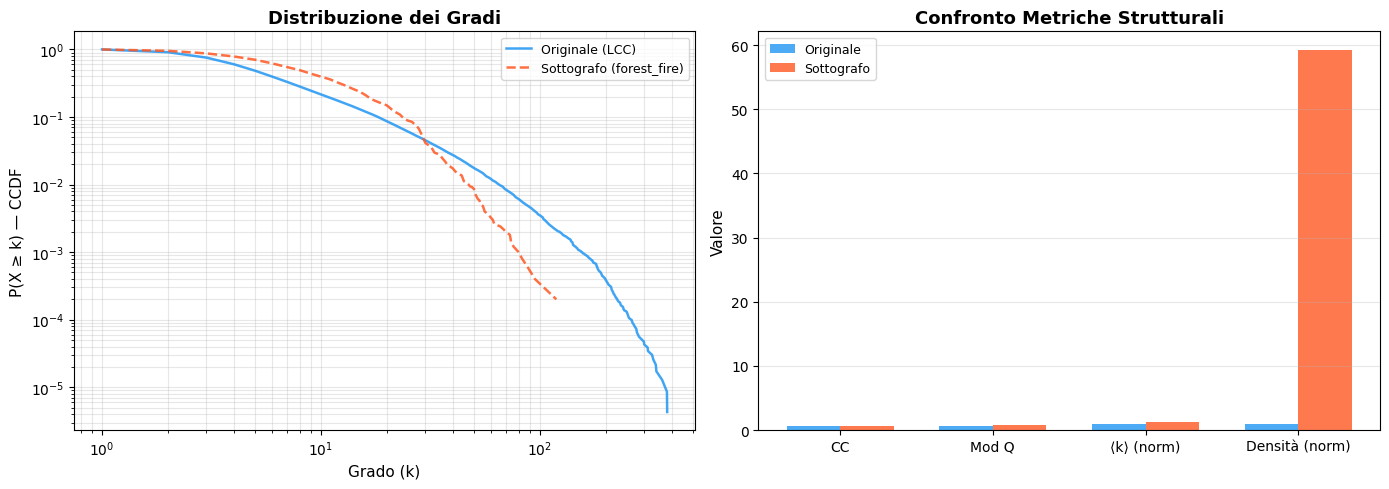

📊 Figura salvata: /kaggle/working/progetto/results/figures/subgraph_validation.png


In [12]:
# --- Validazione strutturale: sottografo vs originale ---
import time

def _quick_metrics(G, label, sample_size=3000):
    """Calcola metriche strutturali chiave per un grafo."""
    t0 = time.time()
    n = G.number_of_nodes()
    degrees = np.array([d for _, d in G.degree()])

    # Clustering (campionato per grafi grandi)
    if n > 10_000:
        sample_nodes = list(np.random.default_rng(42).choice(
            list(G.nodes()), size=min(sample_size, n), replace=False))
        cc = nx.average_clustering(G, nodes=sample_nodes)
    else:
        cc = nx.average_clustering(G)

    # Modularity (label propagation — veloce)
    comms = list(nx.community.label_propagation_communities(G))
    mod_q = nx.community.modularity(G, comms)

    elapsed = time.time() - t0
    return {
        'label': label, 'nodes': n, 'edges': G.number_of_edges(),
        'density': nx.density(G), 'avg_degree': float(degrees.mean()),
        'max_degree': int(degrees.max()), 'std_degree': float(degrees.std()),
        'clustering': cc, 'modularity': mod_q, 'n_communities': len(comms),
        'degree_seq': sorted(degrees, reverse=True), 'time': elapsed,
    }

print('⏳ Calcolo metriche grafo originale (LCC)...')
# Prendi la LCC del grafo completo (gia' in memoria da Cell 13)
lcc_nodes = max(nx.connected_components(G_full), key=len)
G_lcc = G_full.subgraph(lcc_nodes)
m_full = _quick_metrics(G_lcc, 'Originale (LCC)')

print('⏳ Calcolo metriche sottografo...')
m_sub = _quick_metrics(subG, f'Sottografo ({cfg.subgraph.strategy})')

# --- Tabella di confronto ---
print('\n' + '=' * 72)
print('VALIDAZIONE STRUTTURALE — Sottografo vs Originale')
print('=' * 72)
print(f'{"Metrica":<22} {"Originale":>14} {"Sottografo":>14} {"Δ relativo":>14}')
print('-' * 72)

comparisons = [
    ('Nodi',            'nodes',         '%d'),
    ('Archi',           'edges',         '%d'),
    ('Densità',         'density',       '%.6f'),
    ('Grado medio ⟨k⟩', 'avg_degree',   '%.1f'),
    ('Grado max',       'max_degree',    '%d'),
    ('σ(grado)',        'std_degree',    '%.1f'),
    ('Clustering CC',   'clustering',    '%.4f'),
    ('Modularity Q',    'modularity',    '%.4f'),
    ('N. comunità',     'n_communities', '%d'),
]

for label, key, fmt in comparisons:
    v_full = m_full[key]
    v_sub  = m_sub[key]
    if v_full != 0:
        delta_pct = (v_sub - v_full) / abs(v_full) * 100
        delta_s = f'{delta_pct:+.1f}%'
    else:
        delta_s = 'n/a'
    print(f'{label:<22} {fmt % v_full:>14} {fmt % v_sub:>14} {delta_s:>14}')

print('=' * 72)
ratio = m_sub['nodes'] / m_full['nodes'] * 100
print(f'Rapporto campionamento: {ratio:.1f}% dei nodi originali')
print(f'Tempo calcolo: originale={m_full["time"]:.1f}s, sottografo={m_sub["time"]:.1f}s')

# --- Plot: CCDF dei gradi ---
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Degree CCDF (log-log)
    ax = axes[0]
    for m, color, ls in [(m_full, '#2196F3', '-'), (m_sub, '#FF5722', '--')]:
        degs = np.array(m['degree_seq'])
        unique_d = np.sort(np.unique(degs))
        ccdf = np.array([np.mean(degs >= d) for d in unique_d])
        ax.loglog(unique_d, ccdf, ls, color=color, label=m['label'], linewidth=1.8, alpha=0.85)
    ax.set_xlabel('Grado (k)', fontsize=11)
    ax.set_ylabel('P(X ≥ k) — CCDF', fontsize=11)
    ax.set_title('Distribuzione dei Gradi', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

    # Panel 2: Bar chart metriche normalizzate
    ax = axes[1]
    metric_labels = ['CC', 'Mod Q', '⟨k⟩ (norm)', 'Densità (norm)']
    full_vals = [m_full['clustering'], m_full['modularity'], 1.0, 1.0]
    sub_vals = [
        m_sub['clustering'],
        m_sub['modularity'],
        m_sub['avg_degree'] / max(m_full['avg_degree'], 1e-8),
        m_sub['density'] / max(m_full['density'], 1e-8),
    ]
    x = np.arange(len(metric_labels))
    w = 0.35
    ax.bar(x - w/2, full_vals, w, label='Originale', color='#2196F3', alpha=0.8)
    ax.bar(x + w/2, sub_vals, w, label='Sottografo', color='#FF5722', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.set_ylabel('Valore', fontsize=11)
    ax.set_title('Confronto Metriche Strutturali', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fig_path = cfg.project_root / cfg.paths.figures / 'subgraph_validation.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'📊 Figura salvata: {fig_path}')
except Exception as e:
    print(f'⚠️ Plot non disponibile: {e}')

In [13]:
# --- 3. Community detection ---
from src.graph.community import detect_communities, community_stats

print(f'⏳ Community detection (algoritmo={cfg.community.algorithm})...')
community_map, n_comm, q = detect_communities(subG, cfg)
stats = community_stats(subG, community_map)
print(f'✅ Community: {n_comm} trovate | Q={q:.4f}')
print(f'   Dimensioni: min={stats["min_size"]} max={stats["max_size"]} media={stats["mean_size"]:.1f}')

⏳ Community detection (algoritmo=label_propagation)...


[13:34:48] INFO     [Community] Community detection con algoritmo='label_propagation'...

           INFO     [Community] Trovate 415 community | Q=0.8265

           INFO     [Community] Community map salvata: /kaggle/working/progetto/data/processed/community_map.json

✅ Community: 415 trovate | Q=0.8265
   Dimensioni: min=2 max=128 media=12.0


In [14]:
# --- 4. Metriche baseline ---
from src.graph.metrics import compute_all_metrics, compute_centralities

print('⏳ Calcolo metriche baseline...')
baseline_metrics = compute_all_metrics(subG, cfg, community_map=community_map)
centralities = compute_centralities(subG, cfg)

print('\n📊 METRICHE BASELINE (Fase 0)')
print('=' * 40)
for k, v in baseline_metrics.items():
    if isinstance(v, float):
        print(f'  {k:30s}: {v:.4f}')
    elif isinstance(v, int):
        print(f'  {k:30s}: {v:,}')

# Top-5 PageRank
top_pr = sorted(
    [(n, d.get('pagerank', 0)) for n, d in centralities.items()],
    key=lambda x: x[1], reverse=True
)[:5]
print(f'\n  Top-5 PageRank: {[(n, f"{pr:.4f}") for n, pr in top_pr]}')

⏳ Calcolo metriche baseline...


           INFO     [Metrics] Connected components...

           INFO     [Metrics] Clustering coefficient (esatto)...

[13:34:49] INFO     [Metrics] Degree centrality (5000 nodi)...

           INFO     [Metrics] PageRank...

           INFO     [Metrics] Katz centrality (scipy sparse)...


📊 METRICHE BASELINE (Fase 0)
  num_nodes                     : 5,000
  num_edges                     : 26,246
  density                       : 0.0021
  avg_degree                    : 10.4984
  num_connected_components      : 1
  avg_clustering                : 0.6988
  max_degree                    : 119
  min_degree                    : 1
  std_degree                    : 9.7465
  modularity_q                  : 0.8265
  echo_chamber_index            : 0.8318

  Top-5 PageRank: [(3342, '0.0011'), (1316, '0.0009'), (505, '0.0009'), (3612, '0.0008'), (863, '0.0008')]


---
## Fase 1+2 — Agenti LLM e Co-evoluzione

L'**Orchestratore** gestisce l'intera pipeline:
1. Inizializza embeddings, NetworkManager, agenti LLM e pazienti zero
2. Esegue il loop co-evolutivo: **Agenti → GNN fine-tuning → Rewiring**
3. Salva checkpoint e metriche CSV ad ogni step

> 🧠 **LLM reale**: gli agenti usano il server Ollama locale (Llama 3 8B) per generare opinioni e transizioni di stato.
> Non viene usato nessun mock.

In [15]:
# ============================================================
# IMPORT CHECKPOINT DA VERSIONE PRECEDENTE (cross-session Kaggle)
# ============================================================
# Se PREV_VERSION_CKPT_INPUT e' impostato, copia il checkpoint
# dall'output della versione precedente nella directory checkpoints
# del progetto, cosi' RESUME_FROM_CKPT=True trovera' il file.
import shutil
from pathlib import Path

if RESUME_FROM_CKPT and PREV_VERSION_CKPT_INPUT is not None:
    src_ckpt = Path(PREV_VERSION_CKPT_INPUT)
    if not src_ckpt.exists():
        raise FileNotFoundError(f'Checkpoint non trovato: {src_ckpt}')
    ckpt_dir = PROJECT_ROOT / 'results' / 'checkpoints'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    dst = ckpt_dir / src_ckpt.name
    shutil.copy2(src_ckpt, dst)
    print(f'\u2705 Checkpoint importato: {src_ckpt.name} \u2192 {dst}')
elif RESUME_FROM_CKPT:
    # Controlla se esiste gia' un checkpoint locale
    ckpt_dir = PROJECT_ROOT / 'results' / 'checkpoints'
    existing = sorted(ckpt_dir.glob('ckpt_step_*.pkl')) if ckpt_dir.exists() else []
    if existing:
        print(f'\u2705 Checkpoint locale trovato: {existing[-1].name}')
    else:
        print('\u26a0\ufe0f  RESUME_FROM_CKPT=True ma nessun checkpoint trovato.')
        print('   Imposta PREV_VERSION_CKPT_INPUT per importare da versione precedente.')
        RESUME_FROM_CKPT = False  # fallback: nuova run
else:
    print('\u2139\ufe0f  Prima sessione, parto da zero.')

✅ Checkpoint importato: ckpt_step_0093.pkl → /kaggle/working/progetto/results/checkpoints/ckpt_step_0093.pkl


In [16]:
# ============================================================
# IMPORT CSV METRICHE DA VERSIONE PRECEDENTE
# ============================================================
# Se PREV_VERSION_CSV_INPUT e' impostato, copia il CSV dalla
# versione precedente nella directory results/ del progetto.
# L'orchestratore aprira' il CSV in append mode e accodera' i nuovi step,
# mantenendo la storia completa di tutte le sessioni.
import shutil
from pathlib import Path

results_dir = PROJECT_ROOT / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
csv_dst = results_dir / 'metrics_history.csv'

if RESUME_FROM_CKPT and PREV_VERSION_CSV_INPUT is not None:
    src_csv = Path(PREV_VERSION_CSV_INPUT)
    if src_csv.exists():
        shutil.copy2(src_csv, csv_dst)
        import pandas as pd
        df_prev = pd.read_csv(csv_dst)
        print(f'\u2705 CSV metriche importato: {src_csv.name}')
        print(f'   Righe precedenti: {len(df_prev)} step (step {df_prev["step"].min()}..{df_prev["step"].max()})')
    else:
        print(f'\u26a0\ufe0f  CSV non trovato: {src_csv} \u2014 si parte da zero.')
elif RESUME_FROM_CKPT and csv_dst.exists():
    import pandas as pd
    df_prev = pd.read_csv(csv_dst)
    print(f'\u2705 CSV locale trovato: {len(df_prev)} step precedenti')
else:
    print('\u2139\ufe0f  Nessun CSV precedente da importare (prima sessione).')

✅ CSV metriche importato: metrics_history.csv
   Righe precedenti: 94 step (step 0..93)


In [17]:
import uuid
from src.orchestrator import SimulationOrchestrator

print('⏳ Costruzione SimulationOrchestrator...')
orch = SimulationOrchestrator.build_from_config(
    cfg,
    use_mock_llm=USE_MOCK_LLM,
    resume=RESUME_FROM_CKPT,
)
print(f'✅ Orchestratore pronto')
print(f'   Nodi: {orch.network_manager.num_nodes}')
print(f'   Archi: {orch.network_manager.num_edges}')

⏳ Costruzione SimulationOrchestrator...


[13:34:50] INFO     [Seed] Tutti i seed impostati a: 42

           INFO     [SimLogger] Logging su: /kaggle/working/progetto/results/logs/phase2_82d07719.jsonl            
                    (run_id=82d07719)

           INFO     [Embeddings] Caricati da: /kaggle/working/progetto/data/processed/embeddings.npy | shape:      
                    (5000, 128)

[13:34:51] INFO     [Metrics] Degree centrality (5000 nodi)...

...

[13:34:54] INFO     [Checkpoint] Caricato: ckpt_step_0093.pkl (step=93)

           INFO     [Checkpoint] NetworkManager ripristinato (step=93).

           INFO     [Orchestrator] Resume dal step 94 (ultimo checkpoint: step 93).

           INFO     [SimLogger] Run avviata — config_hash=5aea33bf6643

✅ Orchestratore pronto
   Nodi: 5000
   Archi: 27443


In [18]:
# Tracking metriche per step (per i grafici finali)
metrics_history = []

# --- Resume: calcola il range corretto ---
# orch.resume_step = 0 se nuova run, = ckpt_step+1 se resume
start_step = orch.resume_step
end_step   = start_step + PHASE2_STEPS

print(f'\U0001f680 Avvio loop co-evolutivo: step {start_step} \u2192 {end_step - 1} ({PHASE2_STEPS} step questa sessione)...')
print(f'   (PHASE2_STEPS conta gli step di QUESTA sessione, non il totale)')
print('=' * 65)
print(f'{"Step":>5}  {"S":>6}  {"I":>6}  {"R":>6}  {"F":>6}  {"ECI":>8}  {"Loss":>8}  {"Edges":>7}')
print('-' * 65)

for t in range(start_step, end_step):
    step_metrics = orch._run_step(t)
    s_counts = orch.state_summary
    metrics_history.append({'step': t, **step_metrics, **s_counts})

    print(
        f'{t:>5}  {s_counts.get("S",0):>6}  {s_counts.get("I",0):>6}  '
        f'{s_counts.get("R",0):>6}  {s_counts.get("F",0):>6}  '
        f'{step_metrics.get("echo_chamber_index") or 0.0:>8.4f}  '
        f'{step_metrics.get("gnn_loss") or 0.0:>8.4f}  '
        f'{step_metrics.get("num_edges") or 0:>7}'
    )

print('=' * 65)
print(f'\u2705 Loop completato. Step eseguiti: {start_step}\u2013{end_step - 1}')
print(f'   Ultimo checkpoint automatico: ckpt_step_{orch.current_step:04d}.pkl')

🚀 Avvio loop co-evolutivo: step 94 → 93 (0 step questa sessione)...
   (PHASE2_STEPS conta gli step di QUESTA sessione, non il totale)
 Step       S       I       R       F       ECI      Loss    Edges
-----------------------------------------------------------------
✅ Loop completato. Step eseguiti: 94–93
   Ultimo checkpoint automatico: ckpt_step_0094.pkl


In [19]:
# Chiudi il file CSV delle metriche in modo pulito
orch.close()
print('\u2705 Orchestratore chiuso (CSV metriche flushed).')

✅ Orchestratore chiuso (CSV metriche flushed).


📊 Grafico salvato: /kaggle/working/progetto/results/figures/phase2_evolution.png


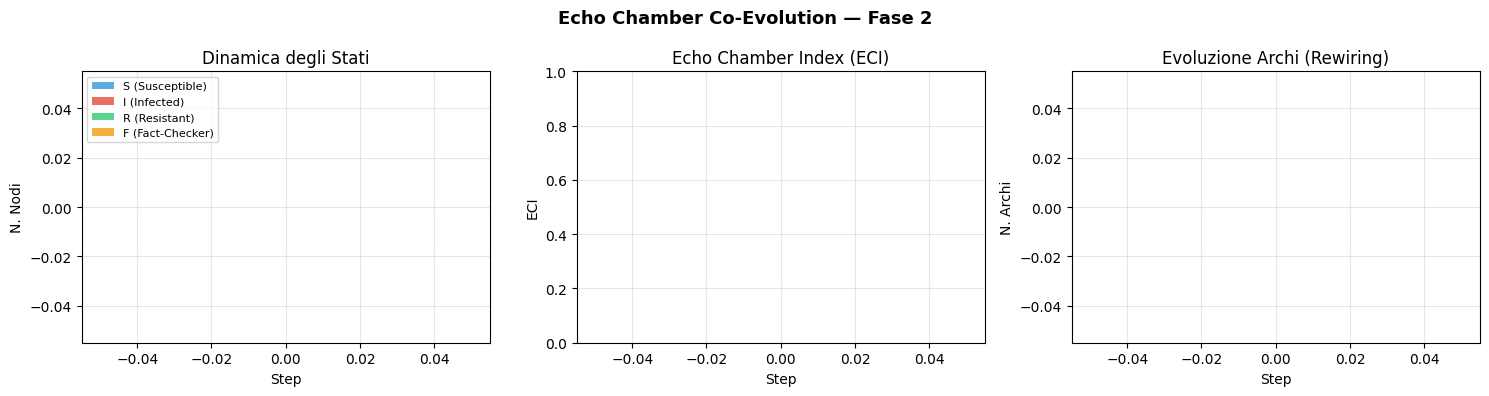

In [20]:
# Visualizzazione evoluzione nel tempo
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    steps = [m['step'] for m in metrics_history]
    n_S = [m.get('S', 0) for m in metrics_history]
    n_I = [m.get('I', 0) for m in metrics_history]
    n_R = [m.get('R', 0) for m in metrics_history]
    n_F = [m.get('F', 0) for m in metrics_history]
    eci = [m.get('echo_chamber_index') or 0.0 for m in metrics_history]
    loss= [m.get('gnn_loss') or 0.0 for m in metrics_history]
    edges=[m.get('num_edges') or 0 for m in metrics_history]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Analisi e Simulazione — Fase 2', fontsize=13, fontweight='bold')
    
    # Plot 1: Dinamica stati
    axes[0].stackplot(steps, n_S, n_I, n_R, n_F,
                      labels=['S (Susceptible)', 'I (Infected)', 'R (Resistant)', 'F (Fact-Checker)'],
                      colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], alpha=0.8)
    axes[0].set_title('Dinamica degli Stati')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('N. Nodi')
    axes[0].legend(loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Echo Chamber Index
    axes[1].plot(steps, eci, color='#8e44ad', linewidth=2, marker='o', markersize=4)
    axes[1].fill_between(steps, eci, alpha=0.2, color='#8e44ad')
    axes[1].set_title('Echo Chamber Index (ECI)')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('ECI')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)
    
    # Plot 3: Archi nel tempo (rewiring)
    axes[2].plot(steps, edges, color='#16a085', linewidth=2, marker='s', markersize=4)
    axes[2].fill_between(steps, edges, alpha=0.2, color='#16a085')
    axes[2].set_title('Evoluzione Archi (Rewiring)')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('N. Archi')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    fig_path = cfg.project_root / cfg.paths.figures / 'phase2_evolution.png'
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'📊 Grafico salvato: {fig_path}')
    plt.show()

except ImportError:
    print('matplotlib non disponibile — skip grafici')

---
## Fase 3 — CELF Fact-Checking

Selezione ottimale dei seed fact-checker tramite **CELF** (Cost-Effective Lazy Forward), iniezione e misurazione dell'impatto.

**Flusso:**
1. Snapshot metriche pre-intervento (baseline)
2. CELF seleziona i `k` nodi ottimali per massimizzare lo spread fact-checking
3. Iniezione: i nodi selezionati diventano Fact-Checker (stato F)
4. N step post-intervento per osservare la propagazione
5. Confronto before/after con delta metriche

> 📊 Il CSV include una colonna `phase` per distinguere step Fase 2 da Fase 3.

In [21]:
from src.graph.metrics import compute_all_metrics
from src.agents.state_machine import StateMachine

# Snapshot pre-intervento
nm_ph3 = orch.network_manager
community_map_ph3 = nm_ph3._community_map

pre_belief_map = nm_ph3.get_belief_map()
pre_metrics = compute_all_metrics(nm_ph3.G, cfg, community_map_ph3, pre_belief_map)
pre_states = nm_ph3.get_all_states()
pre_counts = StateMachine.count_states(pre_states)
n_total = max(nm_ph3.num_nodes, 1)
pre_metrics['infection_rate'] = pre_counts['I'] / n_total
pre_metrics['n_S'] = pre_counts['S']
pre_metrics['n_I'] = pre_counts['I']
pre_metrics['n_R'] = pre_counts['R']
pre_metrics['n_F'] = pre_counts['F']

print('📊 BASELINE PRE-INTERVENTO')
print(f'  S={pre_counts["S"]}  I={pre_counts["I"]}  R={pre_counts["R"]}  F={pre_counts["F"]}')
print(f'  Infection Rate : {pre_metrics["infection_rate"]:.4f}')
print(f'  ECI            : {pre_metrics.get("echo_chamber_index") or 0.0:.4f}')
print(f'  Modularity Q   : {pre_metrics.get("modularity_q") or 0.0:.4f}')

[13:34:56] INFO     [Metrics] Connected components...

           INFO     [Metrics] Clustering coefficient (esatto)...

📊 BASELINE PRE-INTERVENTO
  S=826  I=2573  R=1601  F=0
  Infection Rate : 0.5146
  ECI            : 0.8114
  Modularity Q   : 0.7925


In [22]:
# --- CELF: selezione seed ---
from src.influence.celf import CELF

print(f'⏳ CELF: selezione {CELF_BUDGET_K} seed fact-checker...')
celf = CELF(cfg)
celf_seeds = celf.select(
    G=nm_ph3.G,
    budget_k=CELF_BUDGET_K,
    agent_states=nm_ph3.get_all_states(),
)
print(f'✅ CELF seeds: {celf_seeds}')

# Stima spread
estimated_spread = celf.estimate_spread(nm_ph3.G, celf_seeds, nm_ph3.get_all_states())
print(f'   Spread stimato: {estimated_spread:.1f} nodi ({estimated_spread/n_total*100:.1f}%)')

⏳ CELF: selezione 10 seed fact-checker...


[13:34:57] INFO     [CELF] Avvio selezione: k=10 | candidati=2427 | rounds=30

           INFO     [CELF] Pre-calcolo probabilita' di attivazione archi...

           INFO     [CELF] Calcolo spread iniziale per tutti i candidati [ProcessPool]...

[13:34:58] INFO     [CELF] Iter 1/10: selezionato nodo 4983 (spread=147.13)

...

[13:35:20] INFO     [CELF] Iter 8/10: selezionato nodo 1099 (spread=3.20)

[13:35:42] INFO     [CELF] Iter 9/10: selezionato nodo 4966 (spread=4.47)

[13:35:55] INFO     [CELF] Iter 10/10: selezionato nodo 4195 (spread=2.37)

           INFO     [CELF] Seed selezionati: [4983, 4490, 965, 2693, 4441, 2890, 1927, 1099, 4966, 4195]

✅ CELF seeds: [4983, 4490, 965, 2693, 4441, 2890, 1927, 1099, 4966, 4195]
   Spread stimato: 196.9 nodi (3.9%)


In [23]:
# --- Iniezione fact-checker ---
from src.influence.injector import FactCheckerInjector

injector = FactCheckerInjector(cfg)
injected = injector.inject(nm_ph3, celf_seeds, step=orch.current_step)
print(f'✅ Fact-checker iniettati: {len(injected)} nodi → {injected}')

# Aggiorna stato agenti in memoria
from src.agents.agent import AgentState
for node_id in injected:
    if node_id in orch._agents:
        orch._agents[node_id]._state = AgentState.from_str('F')

           INFO     [Injector] Fact-checker iniettati: 4 | saltati: 6 | nodi: [965, 4441, 2890, 1927]

✅ Fact-checker iniettati: 4 nodi → [965, 4441, 2890, 1927]


In [24]:
# --- Step post-intervento ---
print(f'⏳ Esecuzione {PHASE3_STEPS} step post-intervento...')
post_history = []

# Marca i prossimi step come Fase 3 nel CSV
orch._phase = "3"

start_step = orch.current_step + 1
for t in range(start_step, start_step + PHASE3_STEPS):
    step_metrics = orch._run_step(t)
    s_counts = orch.state_summary
    post_history.append({'step': t, **step_metrics, **s_counts})
    print(
        f'  Step {t}: S={s_counts.get("S",0)} I={s_counts.get("I",0)} '
        f'R={s_counts.get("R",0)} F={s_counts.get("F",0)} '
        f'ECI={step_metrics.get("echo_chamber_index") or 0.0:.4f}'
    )

print('✅ Step post-intervento completati')

⏳ Esecuzione 5 step post-intervento...


           INFO     [Orchestrator] Stocastico: attivati 750 nodi su 5000 (15.0%)

[13:35:56] INFO     [Orchestrator] Attendendo completamento di 624 chiamate LLM...

[13:37:33] INFO     [StateMachine] Nodo 3796: S -> I (lt_infection (f_I=1.00 >= theta=0.29))

[13:37:42] INFO     [StateMachine] Nodo 2723: S -> I (lt_infection (f_I=1.00 >= theta=0.31))

...

           INFO     [StateMachine] Nodo 3485: S -> I (lt_infection (f_I=1.00 >= theta=0.21))

           INFO     [StateMachine] Nodo 1856: S -> I (lt_infection (f_I=0.60 >= theta=0.45))

           INFO       States: S=795 I=2661 R=1540 F=4 | Rewire: +0 -0 | ECI=0.810 | Loss=0.5343

           INFO     [Checkpoint] Salvato: ckpt_step_0099.pkl (step=99)

  Step 99: S=795 I=2661 R=1540 F=4 ECI=0.8105
✅ Step post-intervento completati


In [25]:
# --- Report completo ---
from src.influence.metrics import compute_full_influence_report

final_report = compute_full_influence_report(
    G=nm_ph3.G,
    agent_states=nm_ph3.get_all_states(),
    community_map=community_map_ph3,
    baseline_metrics=pre_metrics,
    cfg=cfg,
)
final_report['celf_seeds'] = celf_seeds
final_report['injected_nodes'] = list(injected)
final_report['n_post_steps'] = PHASE3_STEPS
final_report['sampling_strategy'] = cfg.subgraph.strategy
final_report['forward_prob'] = cfg.subgraph.forward_prob

print('\n' + '=' * 65)
print('CONFRONTO BEFORE / AFTER INTERVENTO CELF')
print('=' * 65)
print(f'{"Metrica":<25}  {"PRIMA":>10}  {"DOPO":>10}  {"DELTA":>10}')
print('-' * 65)

metrics_to_compare = [
    ('Infection Rate',      'infection_rate',       '%.4f'),
    ('Echo Chamber Idx',    'echo_chamber_index',   '%.4f'),
    ('Modularity Q',        'modularity_q',         '%.4f'),
    ('Belief Polarisation', 'belief_polarisation',  '%.4f'),
    ('Nodi S',              'n_S',                  '%d'),
    ('Nodi I',              'n_I',                  '%d'),
    ('Nodi R',              'n_R',                  '%d'),
    ('Nodi F',              'n_F',                  '%d'),
]

for label, key, fmt in metrics_to_compare:
    before = pre_metrics.get(key)
    after  = final_report.get(key)
    delta  = final_report.get(f'delta_{key}')
    before_s = (fmt % before) if before is not None else 'n/a'
    after_s  = (fmt % after)  if after  is not None else 'n/a'
    delta_s  = (f'{delta:+.4f}' if isinstance(delta, float) else
                f'{delta:+d}' if isinstance(delta, int) else 'n/a')
    print(f'{label:<25}  {before_s:>10}  {after_s:>10}  {delta_s:>10}')

print('-' * 65)
print(f'{"Fact-Checker Spread":<25}  {"":>10}  {final_report.get("fcs", 0.0):>10.4f}')
print(f'{"Avg Reach per FC":<25}  {"":>10}  {final_report.get("avg_reach_per_fc", 0.0):>10.1f}')
print('=' * 65)

# --- Salva report JSON ---
import json
report_path = cfg.project_root / cfg.paths.results / 'phase3_report.json'
serializable = {k: v for k, v in final_report.items()
                if isinstance(v, (int, float, str, list, dict, bool, type(None)))}
with open(report_path, 'w') as f:
    json.dump(serializable, f, indent=2)
print(f'\n💾 Report salvato: {report_path}')

[14:44:36] INFO     [InfluenceMetrics] FCS=1.000 | n_FC=4 | avg_reach=5000.0 | total_reach=5000/5000

           INFO     [InfluenceMetrics] Report: infection_rate=0.532 | ECI=0.810 | FCS=1.000 | delta_infection=0.018
                    | n_F=4


CONFRONTO BEFORE / AFTER INTERVENTO CELF
Metrica                         PRIMA        DOPO       DELTA
-----------------------------------------------------------------
Infection Rate                 0.5146      0.5322     +0.0176
Echo Chamber Idx               0.8114      0.8105     -0.0009
Modularity Q                   0.7925      0.7913     -0.0012
Belief Polarisation            0.5577      0.9949     +0.4372
Nodi S                            826         795    -31.0000
Nodi I                           2573        2661    +88.0000
Nodi R                           1601        1540    -61.0000
Nodi F                              0           4     +4.0000
-----------------------------------------------------------------
Fact-Checker Spread                        1.0000
Avg Reach per FC                           5000.0

💾 Report salvato: /kaggle/working/progetto/results/phase3_report.json


📊 Grafico salvato: /kaggle/working/progetto/results/figures/phase3_intervention.png


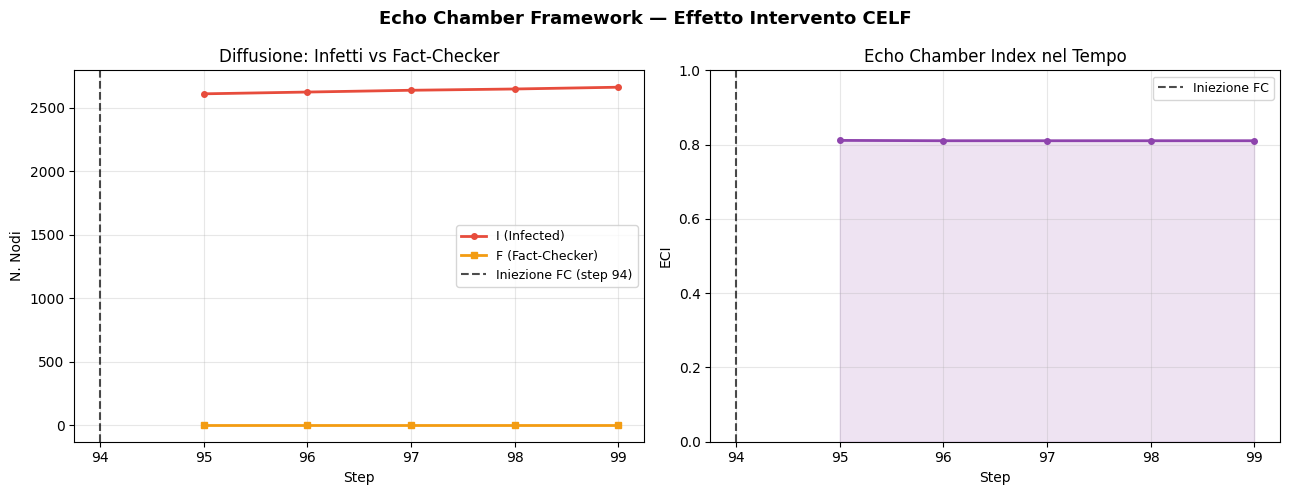

In [26]:
# --- Visualizzazione Phase 3 ---
try:
    import matplotlib.pyplot as plt
    
    # Combina metriche storia completa
    all_history = metrics_history + post_history
    all_steps = [m['step'] for m in all_history]
    all_n_I = [m.get('I', m.get('n_I', 0)) for m in all_history]
    all_n_F = [m.get('F', m.get('n_F', 0)) for m in all_history]
    all_eci = [m.get('echo_chamber_index') or 0.0 for m in all_history]
    
    injection_step = start_step - 1
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Echo Chamber Framework — Effetto Intervento CELF', fontsize=13, fontweight='bold')
    
    # Plot: Nodi I e F nel tempo
    ax1.plot(all_steps, all_n_I, color='#e74c3c', linewidth=2, label='I (Infected)', marker='o', ms=4)
    ax1.plot(all_steps, all_n_F, color='#f39c12', linewidth=2, label='F (Fact-Checker)', marker='s', ms=4)
    ax1.axvline(x=injection_step, color='black', linestyle='--', alpha=0.7, label=f'Iniezione FC (step {injection_step})')
    ax1.set_title('Diffusione: Infetti vs Fact-Checker')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('N. Nodi')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot: ECI nel tempo
    ax2.plot(all_steps, all_eci, color='#8e44ad', linewidth=2, marker='o', ms=4)
    ax2.axvline(x=injection_step, color='black', linestyle='--', alpha=0.7, label=f'Iniezione FC')
    ax2.fill_between(all_steps, all_eci, alpha=0.15, color='#8e44ad')
    ax2.set_title('Echo Chamber Index nel Tempo')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('ECI')
    ax2.set_ylim(0, 1)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    fig_path = cfg.project_root / cfg.paths.figures / 'phase3_intervention.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'📊 Grafico salvato: {fig_path}')
    plt.show()

except ImportError:
    print('matplotlib non disponibile — skip grafici')

---
## Riepilogo Pipeline

In [27]:
import json

pipeline_summary = {
    'config_hash': cfg.config_hash,
    'seed': cfg.execution.random_seed,
    'phase0': {
        'n_nodes': subG.number_of_nodes(),
        'n_edges': subG.number_of_edges(),
        'n_communities': n_comm,
        'modularity_q_baseline': round(q, 4),
        'echo_chamber_index_baseline': round(baseline_metrics.get('echo_chamber_index') or 0.0, 4),
    },
    'phase1': {
        'n_patient_zeros': len(orch._patient_zero_ids),
        'patient_zero_ids': orch._patient_zero_ids,
        'strategy': cfg.simulation.seeder_strategy,
    },
    'phase2': {
        'n_steps': PHASE2_STEPS,
        'llm_mode': 'mock' if USE_MOCK_LLM else 'api',
        'final_state_counts': pre_counts,
        'infection_rate_post_phase2': round(pre_metrics['infection_rate'], 4),
        'eci_post_phase2': round(pre_metrics.get('echo_chamber_index') or 0.0, 4),
    },
    'phase3': {
        'celf_seeds': celf_seeds,
        'injected_nodes': injected,
        'budget_k': CELF_BUDGET_K,
        'n_post_steps': PHASE3_STEPS,
        'fcs': round(final_report.get('fcs', 0.0), 4),
        'delta_infection_rate': round(final_report.get('delta_infection_rate', 0.0), 4),
        'delta_eci': round(final_report.get('delta_echo_chamber_index', 0.0), 4),
        'final_n_F': final_report.get('n_F', 0),
    },
}

summary_path = cfg.project_root / cfg.paths.results / 'pipeline_summary.json'
with open(summary_path, 'w') as f:
    json.dump(pipeline_summary, f, indent=2)

print('\n' + '=' * 60)
print('PIPELINE COMPLETATA ✅')
print('=' * 60)
print(f'  Nodi simulati    : {subG.number_of_nodes()}')
print(f'  Archi iniziali   : {subG.number_of_edges()}')
print(f'  Community        : {n_comm} (Q baseline={q:.4f})')
print(f'  Step Fase 2      : {PHASE2_STEPS}')
print(f'  Infection rate   : {pre_metrics["infection_rate"]:.4f} → {final_report.get("infection_rate", 0.0):.4f}')
print(f'  ECI              : {pre_metrics.get("echo_chamber_index") or 0.0:.4f} → {final_report.get("echo_chamber_index") or 0.0:.4f}')
print(f'  CELF seeds       : {len(celf_seeds)} nodi')
print(f'  FCS post-int.    : {final_report.get("fcs", 0.0):.4f}')
print('=' * 60)
print(f'Riepilogo salvato: {summary_path}')


PIPELINE COMPLETATA ✅
  Nodi simulati    : 5000
  Archi iniziali   : 26246
  Community        : 415 (Q baseline=0.8265)
  Step Fase 2      : 0
  Infection rate   : 0.5146 → 0.5322
  ECI              : 0.8114 → 0.8105
  CELF seeds       : 10 nodi
  FCS post-int.    : 1.0000
Riepilogo salvato: /kaggle/working/progetto/results/pipeline_summary.json


## Visualizzazione Finale: Come è cambiata la Rete
Esegue un confronto visuale tra la struttura della rete all'inizio della simulazione e la struttura alla fine dell'ultimo step, campionando i nodi principali per mantenere il grafico leggibile.

Generazione del grafico riassuntivo in corso...


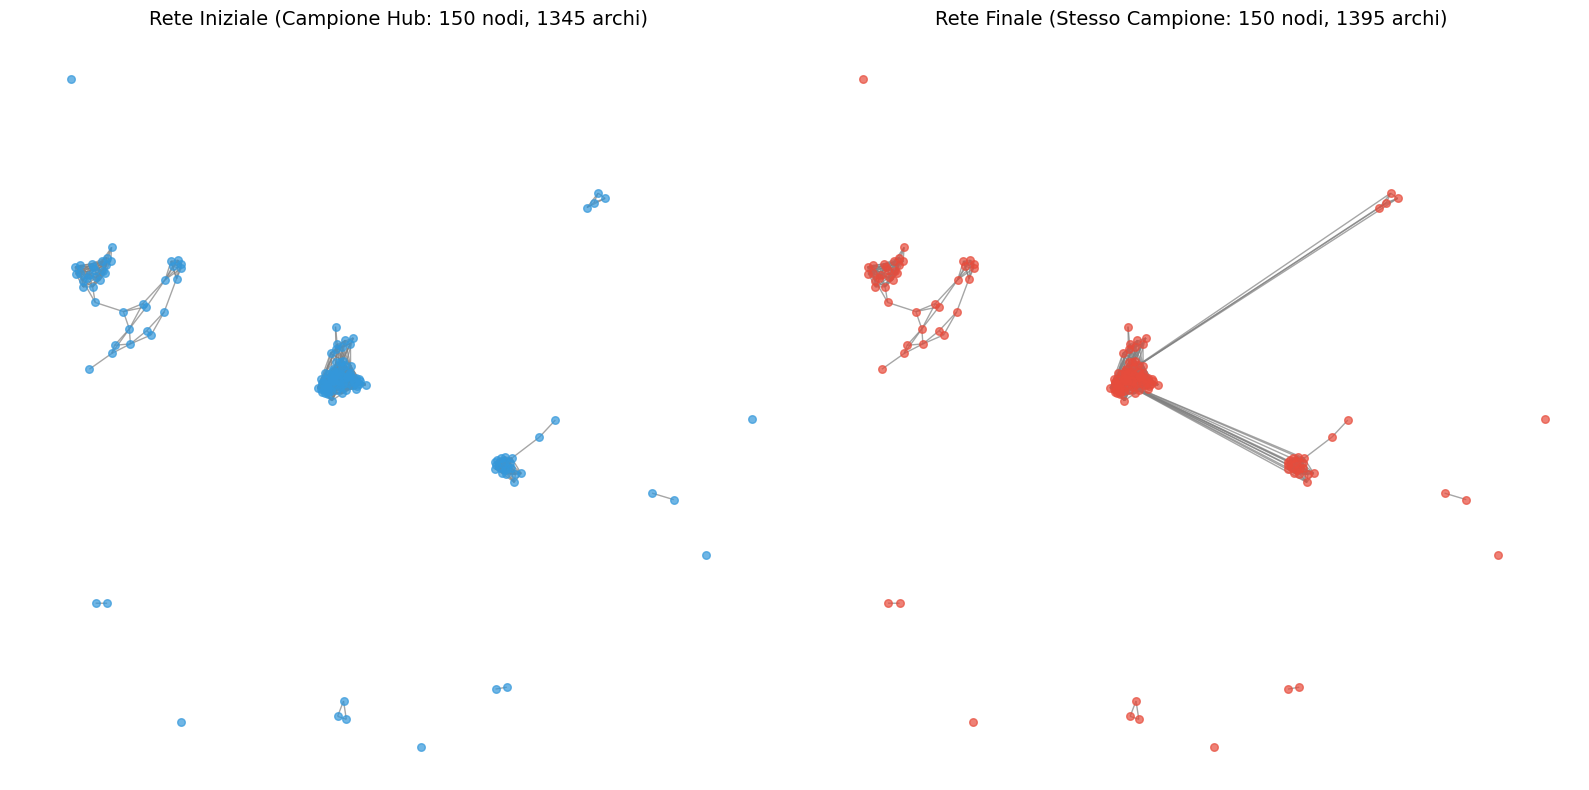

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import glob
import os

# ---------------------------------------------------------
# VISUALIZZAZIONE RIASSUNTIVA: RETE INIZIALE VS RETE FINALE
# ---------------------------------------------------------
print("Generazione del grafico riassuntivo in corso...")

# 1. Carica il grafo iniziale
init_path = 'data/processed/subgraph.gpickle'
if os.path.exists(init_path):
    with open(init_path, 'rb') as f:
        data = pickle.load(f)
    G_init = data['graph'] if isinstance(data, dict) else data
else:
    print("Grafo iniziale non trovato.")
    G_init = None

# 2. Carica l'ultimo checkpoint per la rete finale
checkpoints = sorted(glob.glob('results/checkpoints/ckpt_step_*.pkl'))
if checkpoints and G_init:
    last_ckpt = checkpoints[-1]
    with open(last_ckpt, 'rb') as f:
        ckpt_data = pickle.load(f)
    
    # Estrai il grafo finale dal NetworkManager salvato
    G_final = ckpt_data.graph_payload["graph"]

    # Campionamento: visualizzare 30k nodi creerebbe una macchia nera.
    # Selezioniamo un campione dei 150 nodi più connessi (hub)
    degrees = dict(G_init.degree())
    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:150]
    
    # Estrai i sottografi per il campione
    sub_init = G_init.subgraph(top_nodes)
    sub_final = G_final.subgraph(top_nodes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Fissa il layout in base al grafo iniziale per poter confrontare visivamente
    pos = nx.spring_layout(sub_init, seed=42)
    
    # Disegna Rete Iniziale
    nx.draw(sub_init, pos, ax=ax1, node_size=30, node_color='#3498db', edge_color='gray', alpha=0.7)
    ax1.set_title(f"Rete Iniziale (Campione Hub: {sub_init.number_of_nodes()} nodi, {sub_init.number_of_edges()} archi)", fontsize=14, pad=15)
    
    # Disegna Rete Finale
    nx.draw(sub_final, pos, ax=ax2, node_size=30, node_color='#e74c3c', edge_color='gray', alpha=0.7)
    ax2.set_title(f"Rete Finale (Stesso Campione: {sub_final.number_of_nodes()} nodi, {sub_final.number_of_edges()} archi)", fontsize=14, pad=15)
    
    plt.tight_layout()
    os.makedirs('results/figures', exist_ok=True)
    plt.savefig('results/figures/network_comparison_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Impossibile caricare i dati per il confronto. Verifica che la simulazione abbia salvato i checkpoint.")
